In [1]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil


notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

initializing ocelot...


In [31]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-mono-SASE-double-satellite.yaml')
X.monochromator_target_energy_eV = 8100
X.seed_delay = 0
X.E_seed_uJ = 100
seed_field = tools.Ocelot_SASE_seed_111_dcm_pstxy(X)


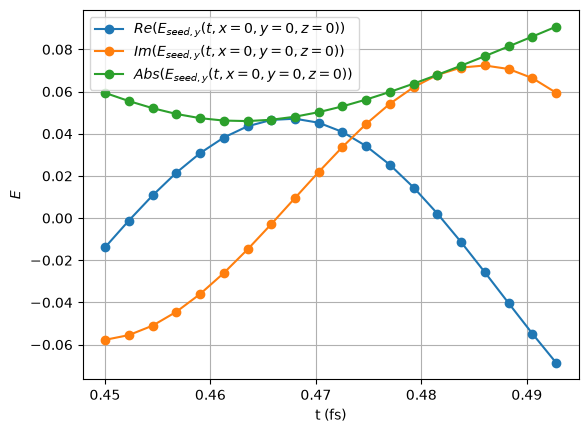

In [32]:

Omega_pstxy = tools.circular_to_linear(X, seed_field)
Omega_t   = Omega_pstxy[0,1,:,int(X.xgrid/2),int(X.ygrid/2)]

t_slice = X.t[200:220]
Omega_slice = Omega_t[200:220]

plt.plot(t_slice, np.real(Omega_slice), "-o", label = r'$Re(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(t_slice, np.imag(Omega_slice), "-o", label = r'$Im(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(t_slice, np.abs(Omega_slice), "-o",label = r'$Abs(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.xlabel('t (fs)')
plt.ylabel(r'$E$')
plt.grid(True)
plt.legend()
plt.show()